<a href="https://colab.research.google.com/github/Suke2004/3d-portfolio/blob/main/brain_tumor_svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import kagglehub
path = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

Using Colab cache for faster access to the 'brain-tumor-classification-mri' dataset.


In [8]:

# Define classes and labels
classes = {
    'no_tumor': 0,
    'pituitary_tumor': 1,
    'glioma_tumor': 2,
    'meningioma_tumor': 3
}

# Dataset training folder path
train_path = os.path.join(path, "Training")

# Load and preprocess dataset
X = []
Y = []

for cls, label in classes.items():

    class_path = os.path.join(train_path, cls)

    for filename in os.listdir(class_path):

        img_path = os.path.join(class_path, filename)

        img = cv2.imread(img_path, 0)   # grayscale

        if img is not None:
            img = cv2.resize(img, (200, 200))
            X.append(img.flatten() / 255.0)
            Y.append(label)

# Convert to numpy arrays
X = np.array(X)
Y = np.array(Y)

print("Dataset loaded successfully")
print("X shape:", X.shape)
print("Y shape:", Y.shape)

Dataset loaded successfully
X shape: (2870, 40000)
Y shape: (2870,)


In [5]:
# Split the dataset into training and testing sets
xtrain, xtest, ytrain, ytest = train_test_split(X, Y, random_state=10, test_size=0.2)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=0.98)
pca_train = pca.fit_transform(xtrain)
pca_test = pca.transform(xtest)

# Train Support Vector Classifier
sv = SVC()
sv.fit(pca_train, ytrain)

# Evaluate the model
train_score = sv.score(pca_train, ytrain)
test_score = sv.score(pca_test, ytest)
print("Training Score:", train_score)
print("Testing Score:", test_score)

Training Score: 0.9651567944250871
Testing Score: 0.8310104529616724


In [11]:
import joblib

joblib.dump(pca, "pca_model.pkl")
joblib.dump(sv, "svm_model.pkl")

print("Models saved successfully")

Models saved successfully


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import joblib

# Split
xtrain, xtest, ytrain, ytest = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=10
)

# Create pipeline
model = Pipeline([
    ('pca', PCA(n_components=0.98)),
    ('svm', SVC())
])

# Train
model.fit(xtrain, ytrain)

# Save entire pipeline
joblib.dump(model, "svm_pca_pipeline.pkl")

print("Pipeline saved")

Pipeline saved


In [ ]:
import joblib
import numpy as np

# Load pipeline
model = joblib.load("svm_pca_pipeline.pkl")

# New sample
new_data = np.array([[5.1, 3.5, 1.4, 0.2]])

# Direct prediction
prediction = model.predict(new_data)

print(prediction)

In [6]:
# Display sample images and predictions
def display_samples(folder, title, num_samples=9):
    plt.figure(figsize=(12, 8))
    c = 1
    for i, filename in enumerate(os.listdir(folder)[:num_samples]):
        img = cv2.imread(os.path.join(folder, filename), 0)
        img = cv2.resize(img, (200, 200)).flatten() / 255.0  # Preprocess the test image
        prediction = sv.predict(pca.transform([img]))  # Predict using the trained SVM

        plt.subplot(3, 3, c)
        plt.title(dec[prediction[0]])  # Map prediction to human-readable label
        plt.imshow(img.reshape(200, 200), cmap='gray')  # Display the image
        plt.axis('off')
        c += 1
    plt.suptitle(title)
    plt.show()

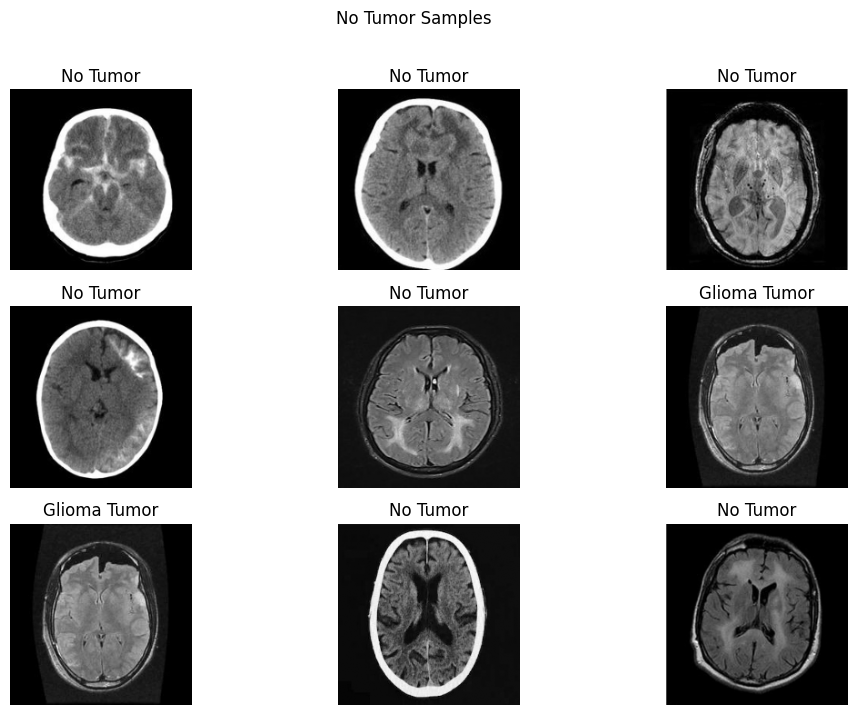

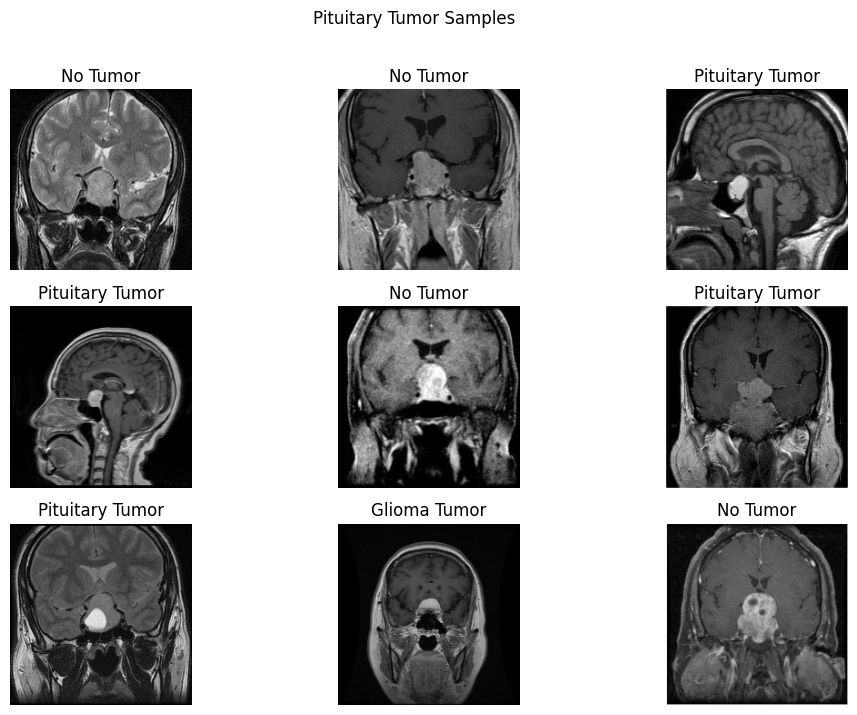

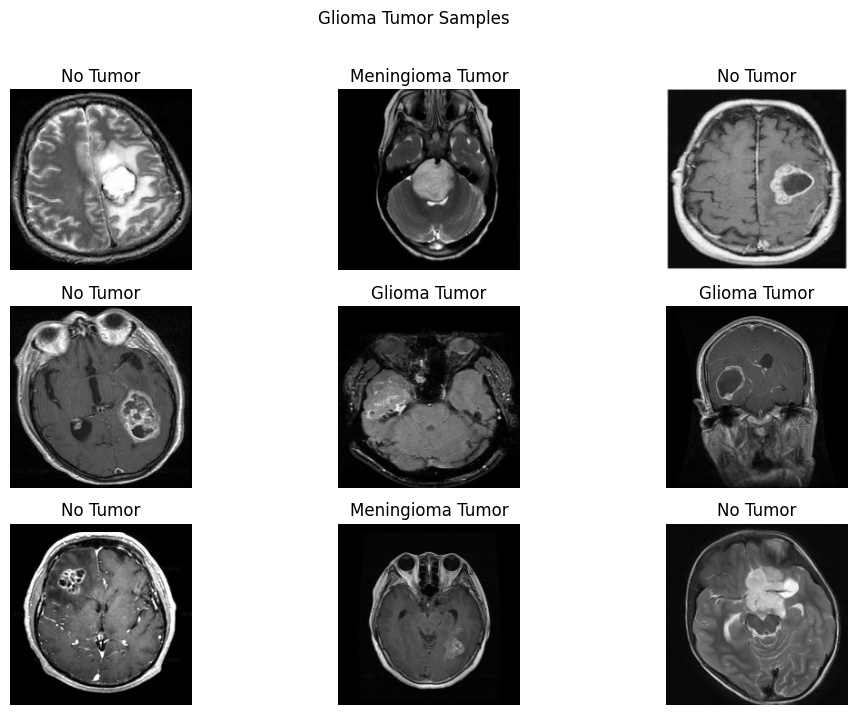

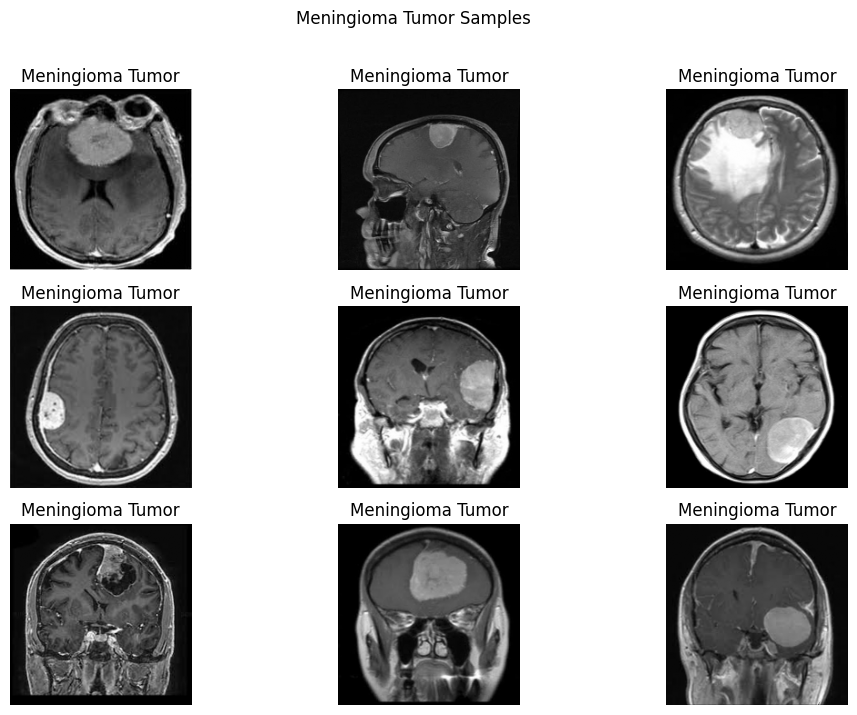

In [7]:
# Define class labels
dec = {0: 'No Tumor', 1: 'Pituitary Tumor', 2: 'Glioma Tumor', 3: 'Meningioma Tumor'}

# Get the base path for the testing dataset
test_path = os.path.join(path, "Testing")

# Display sample images and predictions for each tumor type
tumor_folders = ['no_tumor', 'pituitary_tumor', 'glioma_tumor', 'meningioma_tumor']
for tumor_folder in tumor_folders:
    folder_path = os.path.join(test_path, tumor_folder)
    title = f'{tumor_folder.replace("_", " ").title()} Samples'
    display_samples(folder_path, title)

In [ ]:
import pandas as pd

# Count the occurrences of each tumor type
tumor_counts = {dec[label]: np.sum(Y == label) for label in classes.values()}

# Create a table to represent the tumor counts
table_data = {'Index': range(1, len(classes) + 1), 'Tumor Type': list(tumor_counts.keys()), 'Count': list(tumor_counts.values())}
tumor_table = pd.DataFrame(table_data)

# Apply styling to the table to add cell borders
styled_table = tumor_table.style.set_properties(**{'border': '3px solid black', 'text-align': 'center'})

# Display the styled tumor table
print("\033[1mTumor Type Counts:\033[0m")
display(styled_table)

Tumor Type Counts:


,Index,Tumor Type,Count
0,1,No Tumor,395
1,2,Pituitary Tumor,827
2,3,Glioma Tumor,826
3,4,Meningioma Tumor,822


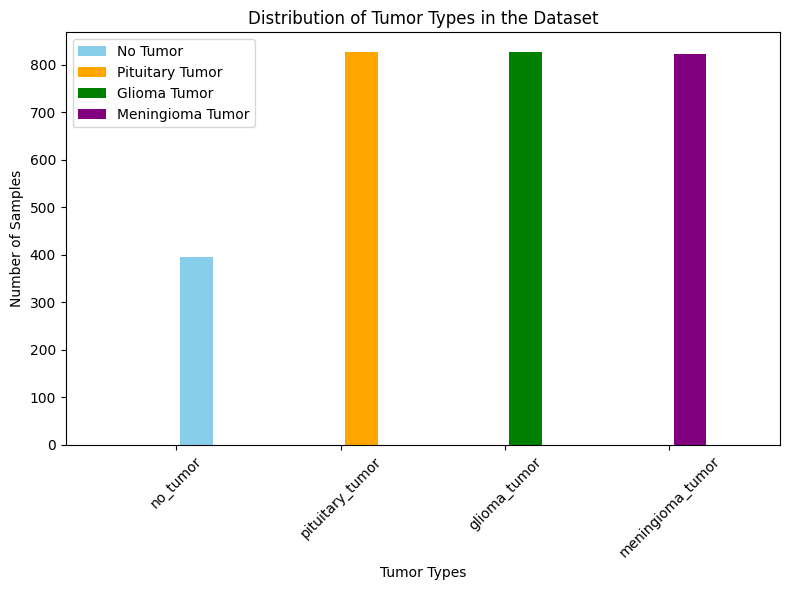

In [ ]:

# Create a histogram of tumor types with different colors
tumor_labels = [dec[label] for label in Y]
colors = ['skyblue', 'orange', 'green', 'purple']

plt.figure(figsize=(8, 6))
for label, color in zip(classes.values(), colors):
    plt.hist(np.array(tumor_labels)[Y == label], bins=len(classes), align='mid', rwidth=0.8, color=color, label=dec[label])
plt.xlabel('Tumor Types')
plt.ylabel('Number of Samples')
plt.title('Distribution of Tumor Types in the Dataset')
plt.xticks(range(len(classes)), list(classes.keys()), rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
import numpy as np

# Class label dictionary
dec = {
    0: 'No Tumor',
    1: 'Pituitary Tumor',
    2: 'Glioma Tumor',
    3: 'Meningioma Tumor'
}

# Count samples for each class
tumor_counts = {
    dec[label]: np.sum(Y == label)
    for label in dec.keys()
}

# Create dataframe
tumor_table = pd.DataFrame({
    'Index': range(1, len(tumor_counts) + 1),
    'Tumor Type': list(tumor_counts.keys()),
    'Count': list(tumor_counts.values())
})

# Style table
styled_table = (
    tumor_table.style
    .set_properties(**{
        'border': '2px solid black',
        'text-align': 'center'
    })
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('border', '2px solid black'),
                ('text-align', 'center'),
                ('background-color', '#f2f2f2')
            ]
        }
    ])
)

print("\033[1mTumor Type Counts:\033[0m")

display(styled_table)

Tumor Type Counts:


,Index,Tumor Type,Count
0,1,No Tumor,395
1,2,Pituitary Tumor,827
2,3,Glioma Tumor,826
3,4,Meningioma Tumor,822


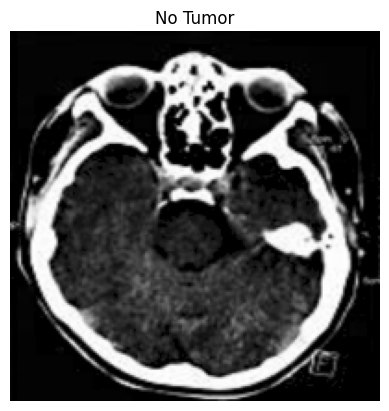

Predicted Class: No Tumor


In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import joblib

# Load saved pipeline
model = joblib.load("svm_pca_pipeline.pkl")

# Class labels
dec = {
    0: 'No Tumor',
    1: 'Pituitary Tumor',
    2: 'Glioma Tumor',
    3: 'Meningioma Tumor'
}

# Image size used during training
IMG_SIZE = 200

def predict_single_image(image_path):

    # Read image in GRAYSCALE
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Resize
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Flatten
    img_flat = img_resized.flatten().reshape(1, -1)

    # Predict
    pred = model.predict(img_flat)[0]

    # Show image
    plt.imshow(img_resized, cmap='gray')
    plt.title(dec[pred])
    plt.axis("off")
    plt.show()

    return dec[pred]

# Example usage
image_path = "test_image.png"

result = predict_single_image(image_path)

print("Predicted Class:", result)